In [8]:
import os 
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

DATA_PATH = Path('..') / 'data' / 'raw' / 'city_day.csv'
if not DATA_PATH.exists():
    DATA_PATH = Path('data') / 'raw' / 'city_day.csv'

df = pd.read_csv(DATA_PATH)
print('SHAPE = ', df.shape)
df.head()

SHAPE =  (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [15]:
print("Date range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nNumber of cities:", df["City"].nunique())
print(sorted(df["City"].dropna().unique()))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate City-Date pairs:", df.duplicated(["City", "Date"]).sum())

print("\nTarget missing values:")
print(df["AQI"].isna().sum())

Date range:
2015-01-01 to 2020-07-01

Number of cities: 26
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

Duplicate rows: 0
Duplicate City-Date pairs: 0

Target missing values:
4681


,missing_count,missing_percent
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


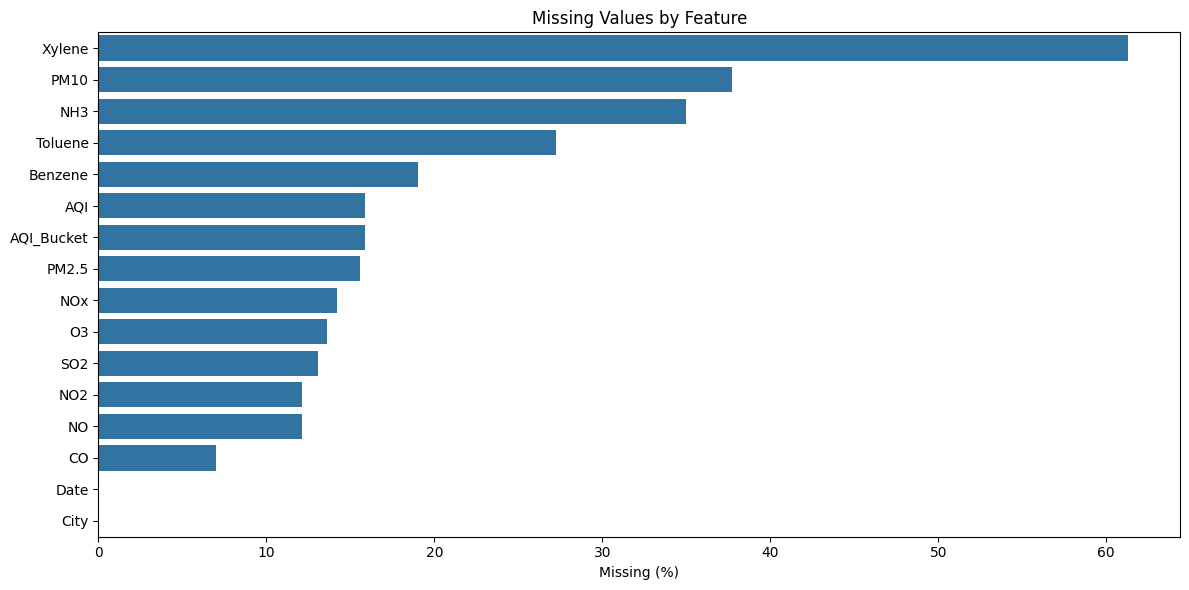

In [16]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(
        missing_percent=lambda x: 100 * x["missing_count"] / len(df)
    )
    .sort_values("missing_percent", ascending=False)
)

display(missing)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=missing["missing_percent"].values,
    y=missing.index
)
plt.title("Missing Values by Feature")
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


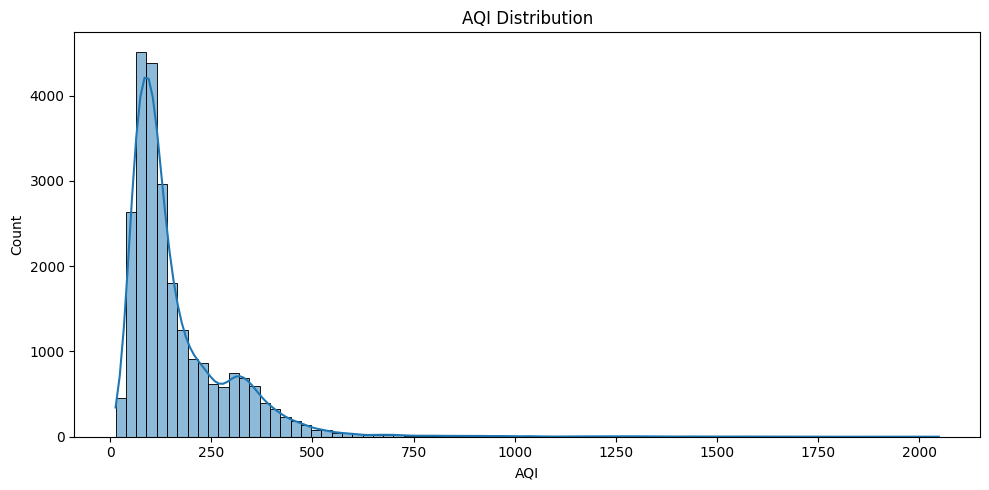


AQI category distribution:


,count
AQI_Bucket,
Moderate,8829
Satisfactory,8224
NaN,4681
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


In [17]:
print(df["AQI"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["AQI"].dropna(), bins=80, kde=True)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.tight_layout()
plt.show()

print("\nAQI category distribution:")
display(df["AQI_Bucket"].value_counts(dropna=False).to_frame("count"))

In [19]:
bucket_stats = (
    df.dropna(subset=["AQI", "AQI_Bucket"])
      .groupby("AQI_Bucket")["AQI"]
      .agg(["count", "min", "max", "mean", "median"])
      .sort_values("min")
)

display(bucket_stats)

print("AQI maximum:", df["AQI"].max())
print("Rows with AQI > 500:", (df["AQI"] > 500).sum())
print("Rows with AQI > 1000:", (df["AQI"] > 1000).sum())

,count,min,max,mean,median
AQI_Bucket,,,,,
Good,1341,13.0,50.0,40.268456,43.0
Satisfactory,8224,51.0,100.0,76.765686,77.0
Moderate,8829,101.0,200.0,136.671877,130.0
Poor,2781,201.0,300.0,245.663430,242.0
Very Poor,2337,301.0,400.0,343.004279,340.0
Severe,1338,401.0,2049.0,567.886398,474.0


AQI maximum: 2049.0
Rows with AQI > 500: 543
Rows with AQI > 1000: 93


,count,mean,median,min,max
City,,,,,
Ahmedabad,1334,452.122939,384.5,48.0,2049.0
Delhi,1999,259.487744,257.0,29.0,716.0
Patna,1459,240.782042,215.0,53.0,619.0
Gurugram,1453,225.123882,208.0,38.0,891.0
Lucknow,1893,217.973059,198.0,39.0,707.0
Talcher,698,172.886819,128.5,13.0,570.0
Jorapokhar,771,159.251621,133.0,27.0,604.0
Brajrajnagar,713,150.280505,122.0,22.0,355.0
Kolkata,754,140.566313,94.0,26.0,475.0


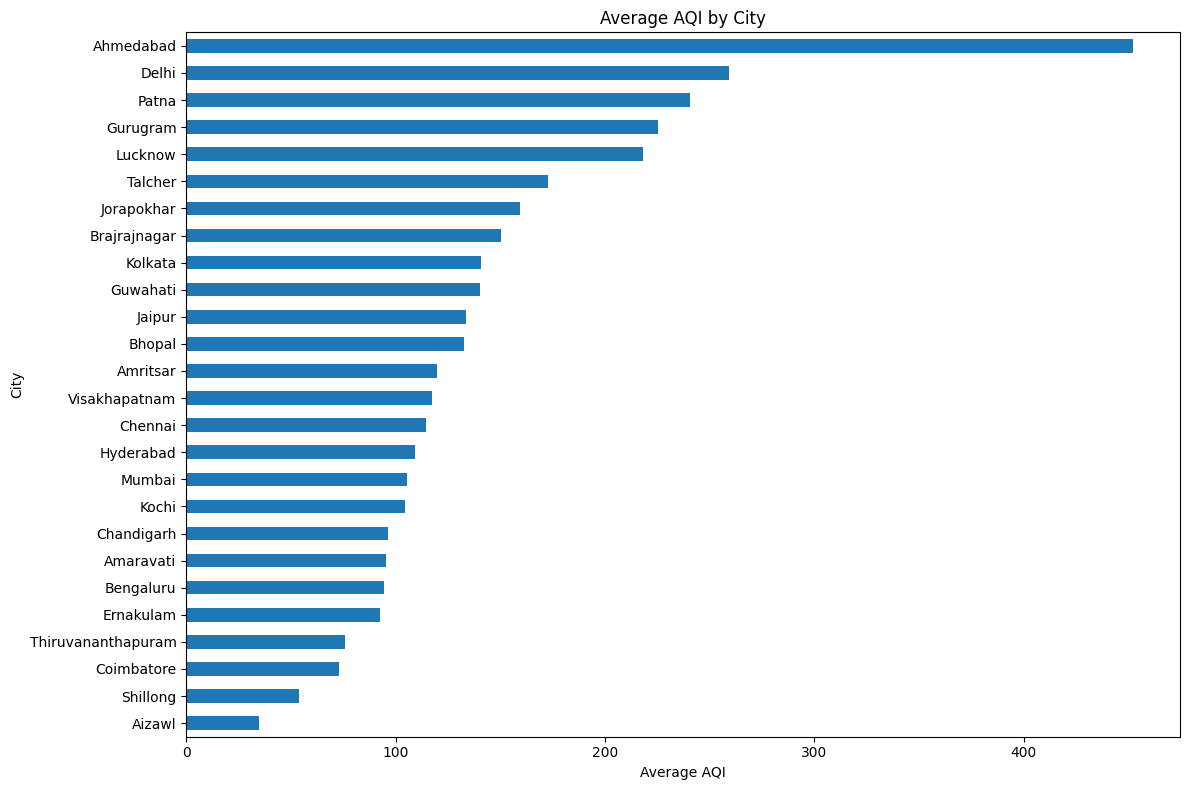

In [20]:
city_stats = (
    df.groupby("City")["AQI"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)

display(city_stats)

plt.figure(figsize=(12, 8))
city_stats["mean"].sort_values().plot(kind="barh")
plt.title("Average AQI by City")
plt.xlabel("Average AQI")
plt.ylabel("City")
plt.tight_layout()
plt.show()

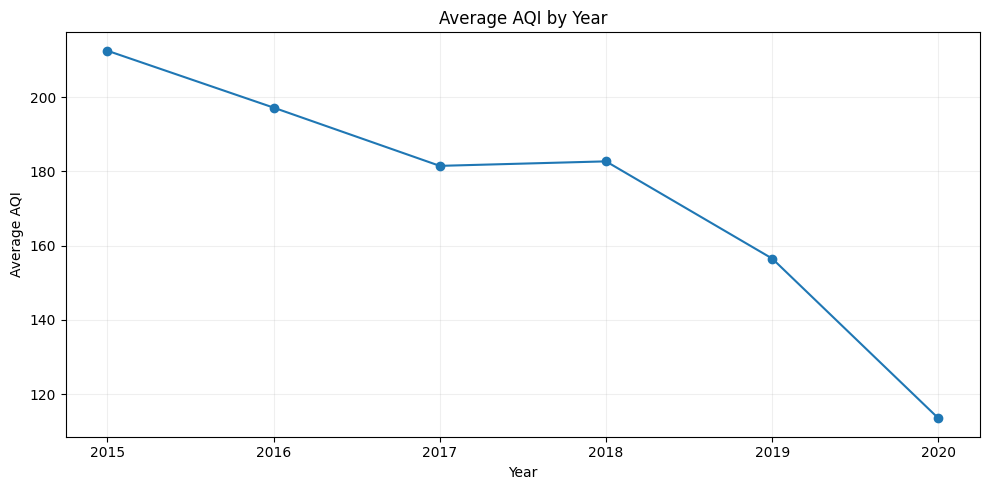

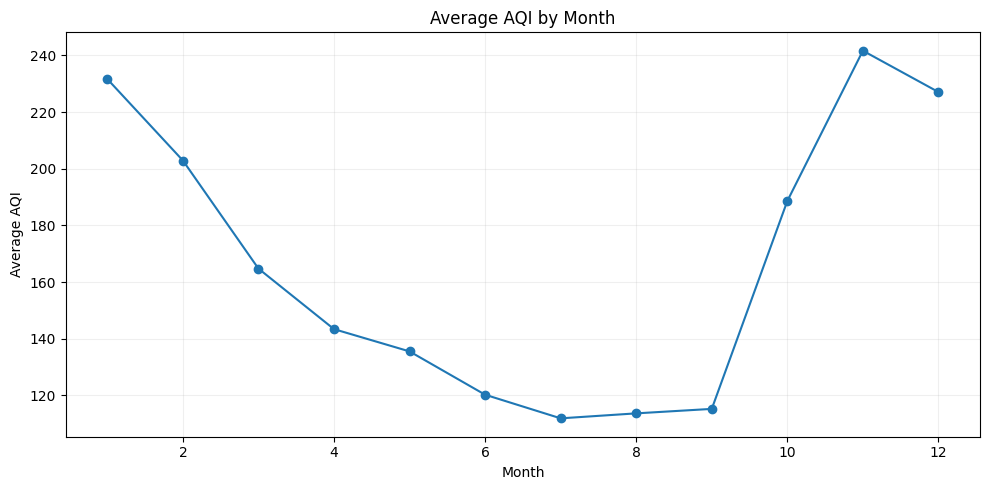

In [21]:
temp = df.copy()
temp["Date"] = pd.to_datetime(temp["Date"], errors="coerce")
temp["Year"] = temp["Date"].dt.year
temp["Month"] = temp["Date"].dt.month
temp["MonthName"] = temp["Date"].dt.month_name()

yearly = temp.groupby("Year")["AQI"].mean()
monthly = temp.groupby("Month")["AQI"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
yearly.plot(marker="o", ax=ax)
ax.set_title("Average AQI by Year")
ax.set_ylabel("Average AQI")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(marker="o", ax=ax)
ax.set_title("Average AQI by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03


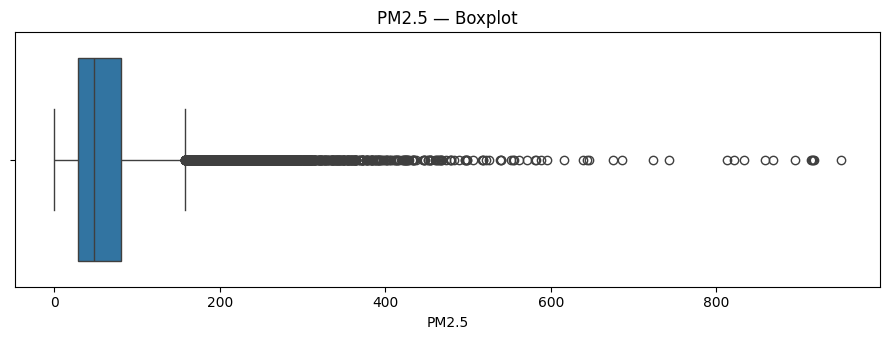

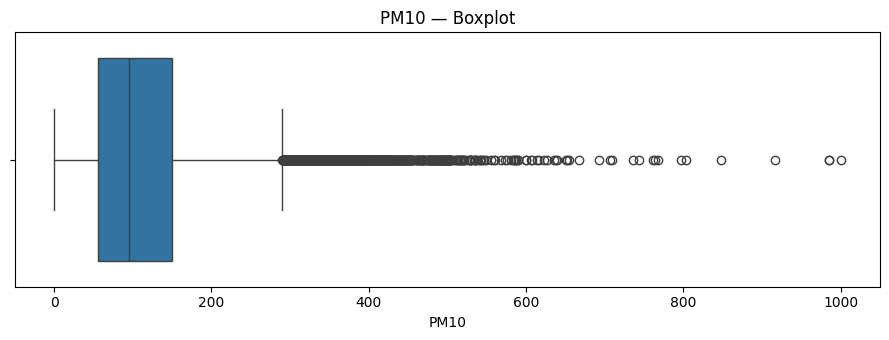

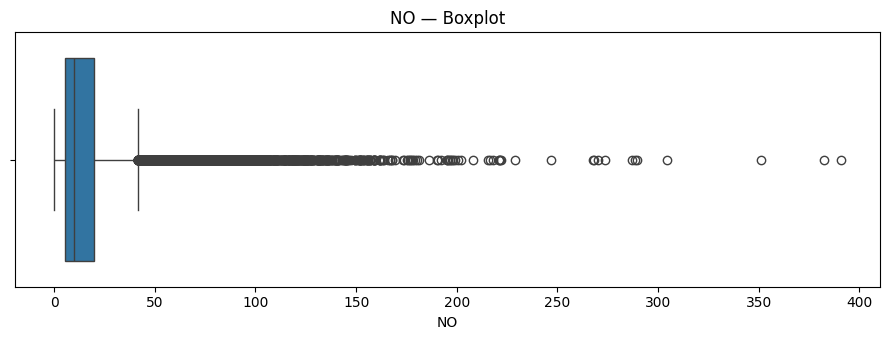

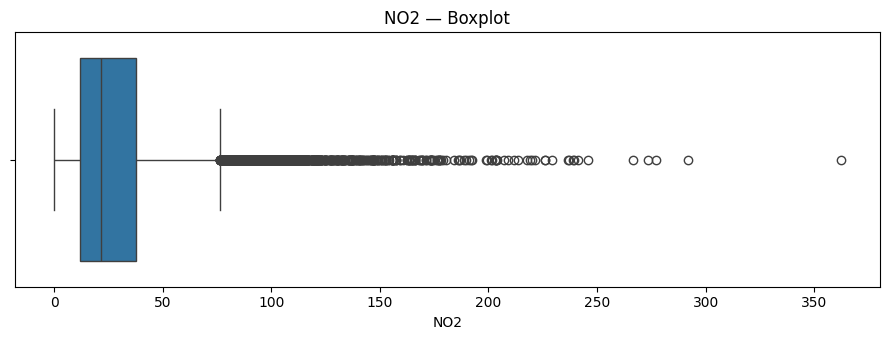

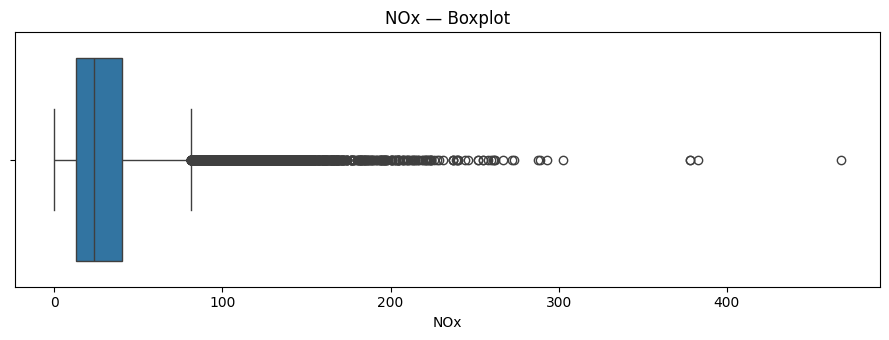

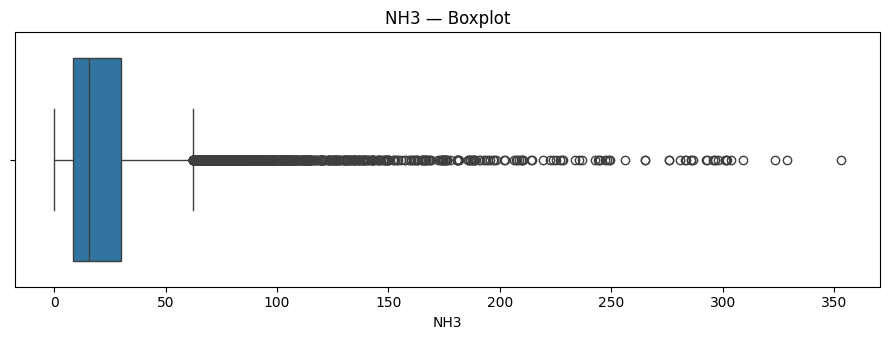

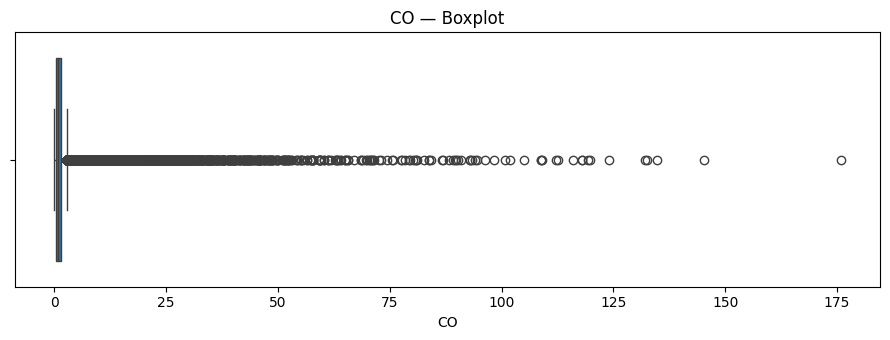

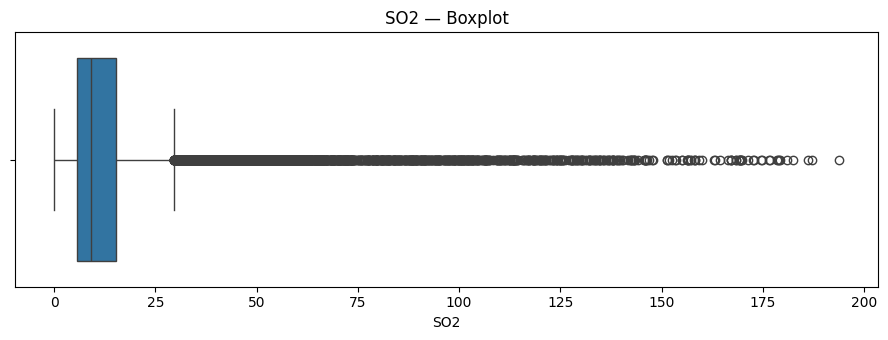

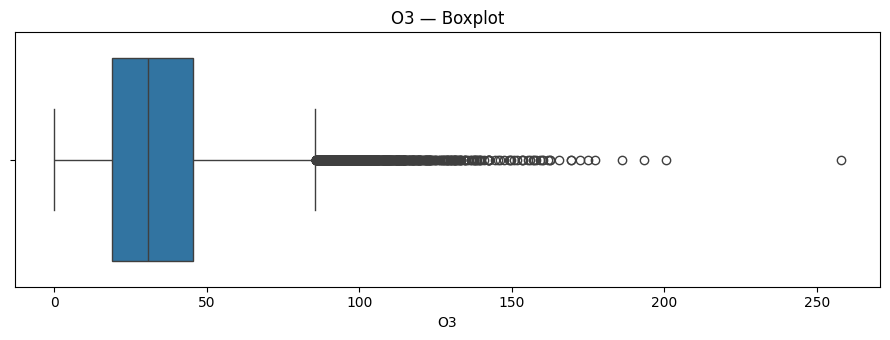

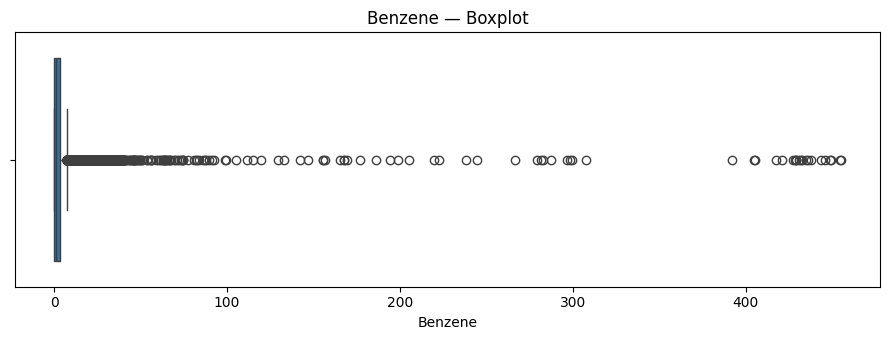

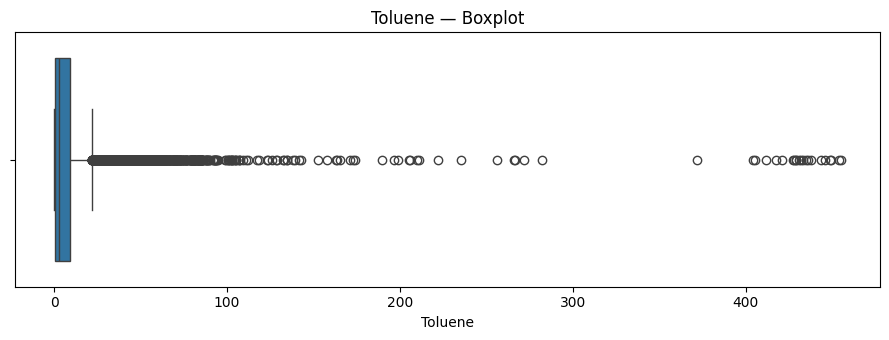

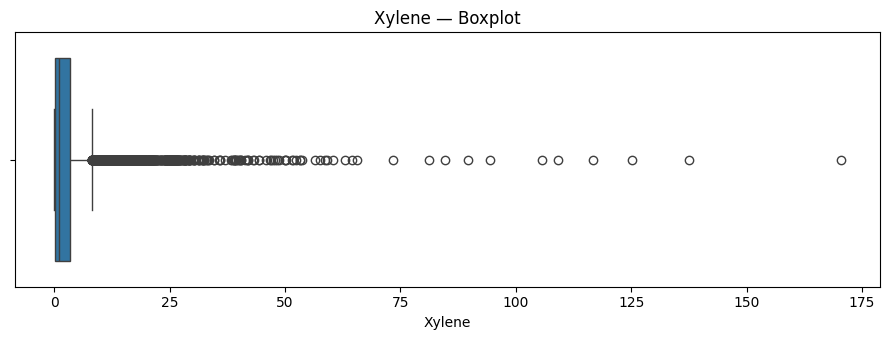

In [22]:
pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
    "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"
]

display(df[pollutants].describe().T)

for col in pollutants:
    plt.figure(figsize=(9, 3.5))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — Boxplot")
    plt.tight_layout()
    plt.show()

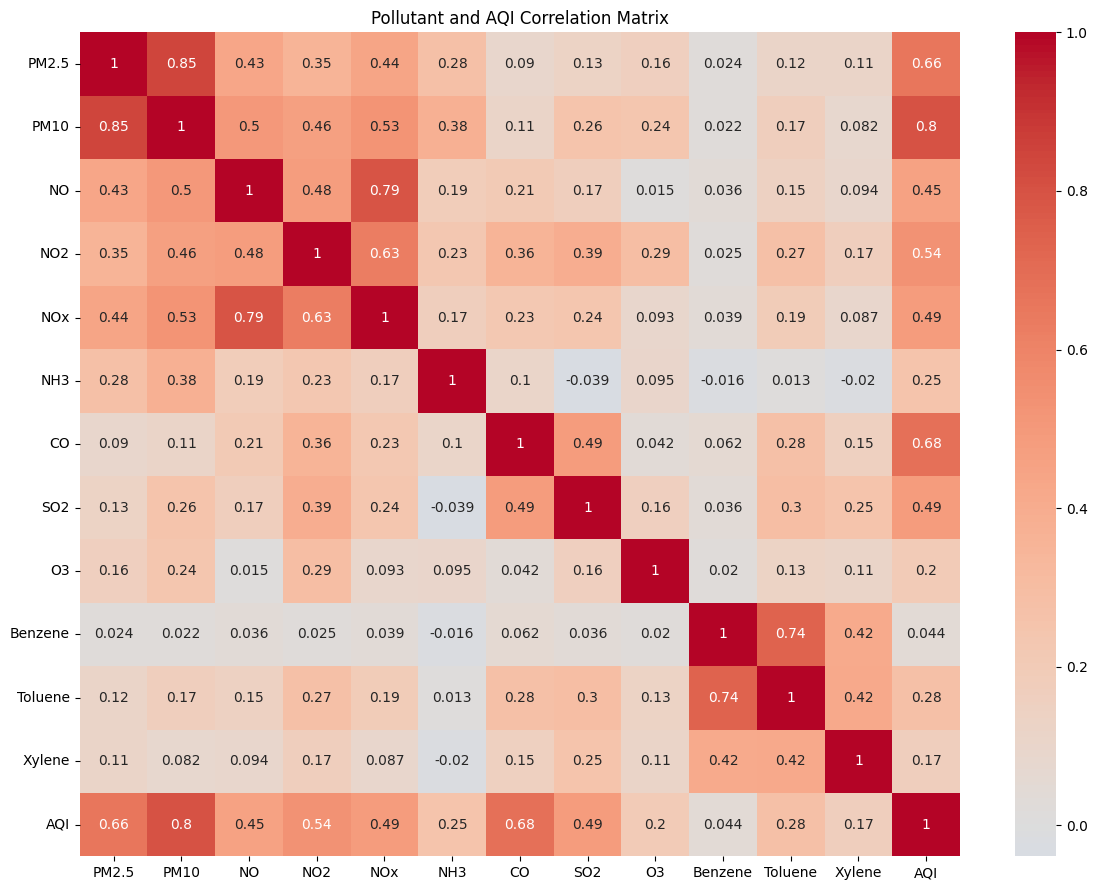

,absolute_correlation_with_AQI
PM10,0.803313
CO,0.683346
PM2.5,0.659181
NO2,0.537071
SO2,0.490586
NOx,0.486450
NO,0.452191
Toluene,0.279992
NH3,0.252019
O3,0.198991


In [24]:
numeric_cols = pollutants + ["AQI"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True
)
plt.title("Pollutant and AQI Correlation Matrix")
plt.tight_layout()
plt.show()

aqi_corr = (
    corr["AQI"]
    .drop("AQI")
    .abs()
    .sort_values(ascending=False)
)

display(aqi_corr.to_frame("absolute_correlation_with_AQI"))

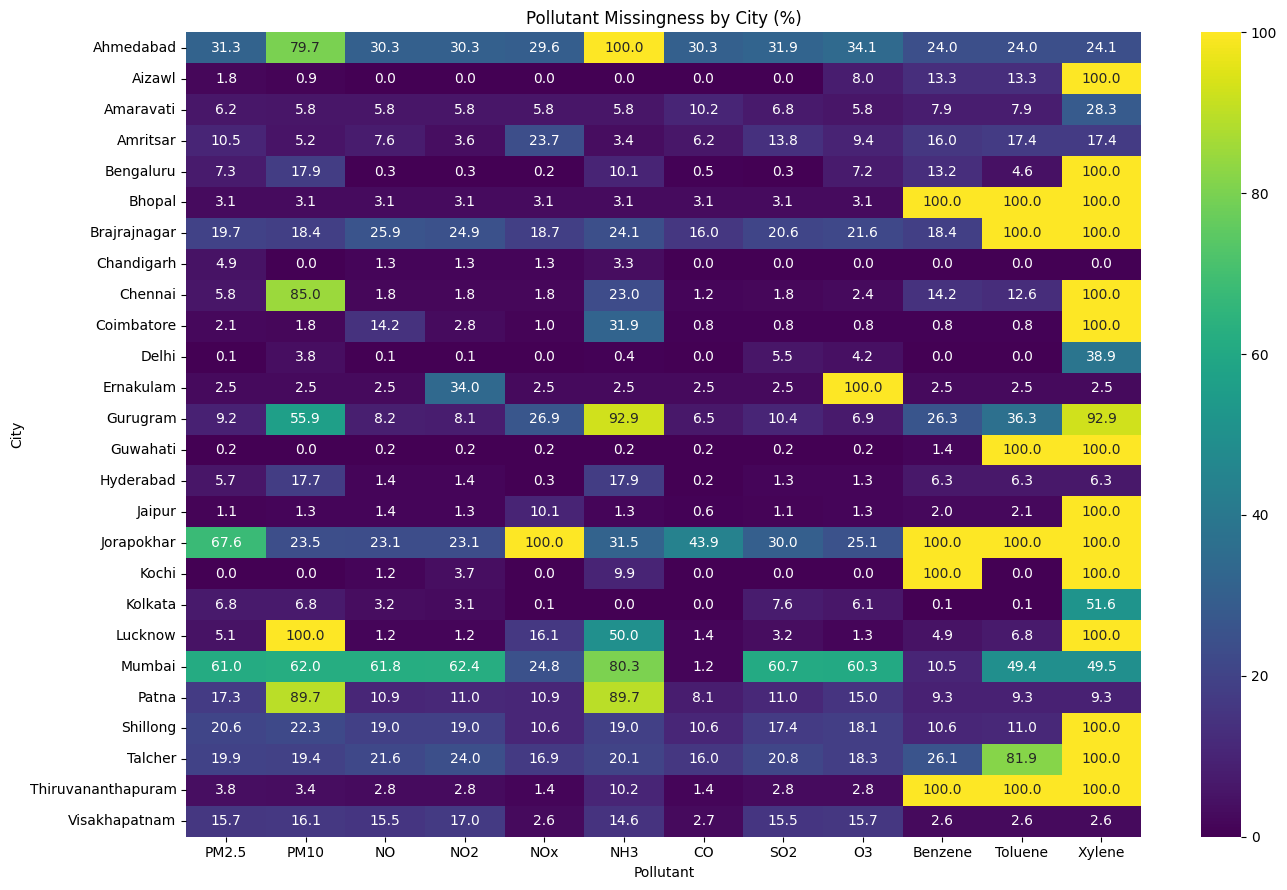

In [28]:
city_missing = (
    df.groupby("City")[pollutants]
      .apply(lambda x: x.isna().mean() * 100)
)

plt.figure(figsize=(14, 9))
sns.heatmap(city_missing, cmap="viridis", annot=True, fmt=".1f")
plt.title("Pollutant Missingness by City (%)")
plt.xlabel("Pollutant")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [29]:
df["Date"] = pd.to_datetime(df["Date"])

train = df[df["Date"] < "2020-01-01"]
test = df[df["Date"] >= "2020-01-01"]

print("Train:", train.shape)
print("Test :", test.shape)
print("Train date:", train["Date"].min(), "to", train["Date"].max())
print("Test date :", test["Date"].min(), "to", test["Date"].max())

Train: (24885, 16)
Test : (4646, 16)
Train date: 2015-01-01 00:00:00 to 2019-12-31 00:00:00
Test date : 2020-01-01 00:00:00 to 2020-07-01 00:00:00
